# Beyond RFM: A Machine Learning Approach to Customer Segmentation

In my previous analysis, I grouped customers based on their orders in terms of recency, 
frequency, and monetary value (RFM) — a model businesses typically use to identify 
distinct customer groups. As a student studying mathematics and computer science, 
I couldn't help but wonder how a machine would group customers instead, and how 
different its groupings would be from an RFM-based approach.

In this analysis, I'll be exploring two main questions:
1. How does a machine group Starbucks' customers using recency, frequency, and 
   monetary value, and how do these groupings differ from the RFM-based groups?
2. Aside from recency, frequency, and monetary value, what other characteristics 
   define these different customer groups?


In [139]:
# packages and data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, fowlkes_mallows_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from validclust import dunn
from IPython.core.display import HTML

path = kagglehub.dataset_download("likithagedipudi/starbucks-customer-ordering-patterns")

csv = os.listdir(path)

data = pd.read_csv(path + f'/{csv[0]}')

rfm_data = pd.read_csv('data/rfm_data.csv')[['Recency', 'Frequency', 'Monetary', 'Customer Status']]

rfm_data.head()



,Recency,Frequency,Monetary,Customer Status
0,40,12,174.60,Loyal Customers
1,61,13,207.18,Loyal Customers
2,83,5,79.71,Need Attention
3,145,7,95.85,At Risk
4,79,3,47.45,Need Attention



## I. Clustering with Recency and Frequency

To address the first question, I will cluster customers based on recency and frequency. Why not monetary, you may ask?

Well, as shown below, frequency and monetary is highly positively correlated (~0.93), so if clustering were to account for all three variables, clustering will be biased as there will be more weighting towards the information that frequency and monetary is demonstrating, as they reveal very similar information. As such, in order to reduce such bias, recency and frequency will be the only variables accounted to provide sufficient information for clustering. 

<Axes: >

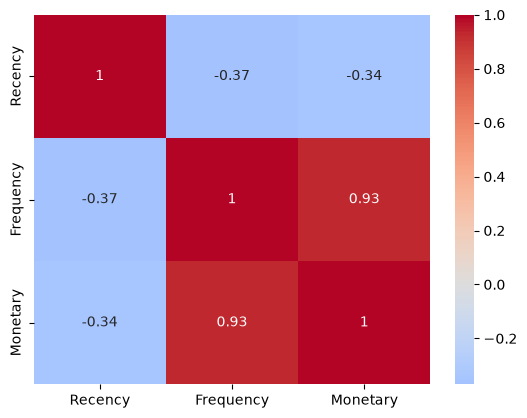

In [140]:
# Multivariate EDA: Correlation Heatmap
corr = rfm_data.select_dtypes('number').corr()

sns.heatmap(corr, cmap="coolwarm", annot=True, annot_kws={"size": 10}, center=0)

# Frequency and Monetary is highly positively correlated; Frequency and Recency is slightly inversely correlated; Monetary and Recency is slightly inversely correlated

To cluster, I will implement kmeans. Kmeans is an unsupervised machine learning algorithm used for classifying data into k partitions based on similarity. The algorithm will appoint k centroids corresponding the number of clusters we the users set, and assign each data point to a cluster based on their distance from a centroid. The closer a data point is to a centroid, the higher the likelihood they will be assigned to that cluster the centroid is in. 

Because kmeans rely on distance to group data points, standardization will be necessary, as recency and frequency have various ranges.

Text(0.5, 1.0, 'Distribution of Frequent Orders')

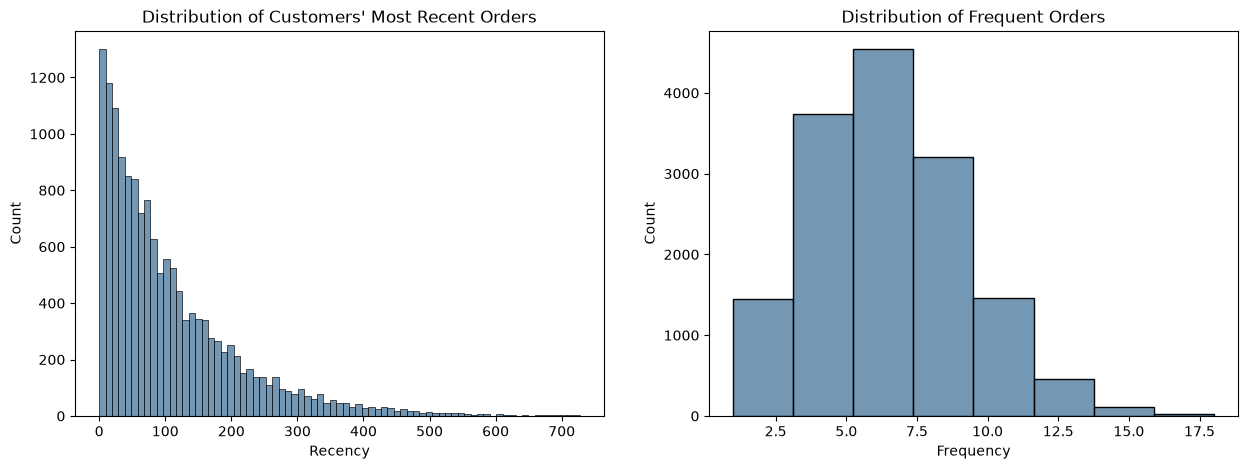

In [141]:
# RFM Histogram

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

recency_hist = sns.histplot(rfm_data['Recency'], color="#46769B", ax=axes[0])
axes[0].set_title("Distribution of Customers' Most Recent Orders")

frequency_hist = sns.histplot(rfm_data['Frequency'], color = "#46769B", binwidth=2, ax=axes[1])
axes[1].set_title("Distribution of Frequent Orders")


In [142]:
rfm_kmeans = rfm_data[['Recency', 'Frequency']]
# Standardizing recency and frequency
scaler = StandardScaler()
rfm_normalized = scaler.fit_transform(rfm_kmeans)


After standardizing recency and frequency, we can utilize an elbow plot to visualize the decrease of within-cluster sum of squares (WCSS) across a range of clusters. Ideally, we want lower WCSS values, as they indicate more compactness and higher quality of clusters. To identify the optimal number of clusters, k, we'll have to look at where the rate of WCSS decline decreases. In other words, the concave point of an elbow.  

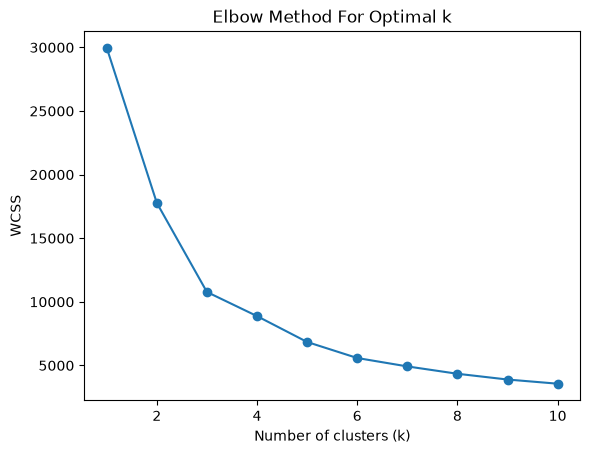

In [163]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=28)
    kmeans.fit(rfm_normalized)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

Looking at the elbow plot, 3 looks like the first point where there's a noticeable shift in the decline of WCSS. Let's add this to our dataset. 

In [164]:

model = KMeans(n_clusters=3, random_state=28)
rfm_data['Group'] = model.fit_predict(rfm_normalized) + 1


h1 = rfm_data.query("Group == 1")[['Recency', 'Frequency', 'Monetary', 'Group']].head().style.set_caption("Group 1")

h2 = rfm_data.query("Group == 2")[['Recency', 'Frequency', 'Monetary', 'Group']].head().style.set_caption("Group 2")

h3 = rfm_data.query("Group == 3")[['Recency', 'Frequency', 'Monetary', 'Group']].head().style.set_caption("Group 3")


def multi_table(table_list):
    ''' Accepts a list of IpyTable objects and returns a table which contains each IpyTable in a cell
    '''
    return HTML(
        '<table><tr style="background-color:white;">' + 
        ''.join(['<td>' + table._repr_html_() + '</td>' for table in table_list]) +
        '</tr></table>'
    )

multi_table([h1, h2, h3])




,Recency,Frequency,Monetary,Group
2,83,5,79.710000,1
3,145,7,95.850000,1
4,79,3,47.450000,1
6,23,5,67.620000,1
7,76,6,99.710000,1
,Recency,Frequency,Monetary,Group
0,40,12,174.600000,2
1,61,13,207.180000,2
5,81,8,128.880000,2
9,179,8,104.400000,2


Characteristics defining each group:

Group 1:
Moderate Frequency, Monetary, and Recency

Group 2:
High Frequency and Monetary

Group 3:
Low Recency, Frequency, and Monetary

In [146]:
h4 = rfm_data.query("Group == 1")[['Group', 'Customer Status']].groupby('Customer Status', as_index=False).size()
h4 = pd.DataFrame(h4).sort_values('size', ascending=False).reset_index(drop=True).style.set_caption("Group 1")

h5 = rfm_data.query("Group == 2")[['Group', 'Customer Status']].groupby('Customer Status', as_index=False).size()
h5 = pd.DataFrame(h5).sort_values('size', ascending=False).reset_index(drop=True).style.set_caption("Group 2")

h6 = rfm_data.query("Group == 3")[['Group', 'Customer Status']].groupby('Customer Status', as_index=False).size()
h6 = pd.DataFrame(h6).sort_values('size', ascending=False).reset_index(drop=True).style.set_caption("Group 3")

multi_table([h4, h5, h6])


,Customer Status,size
0,Potential Loyalists,2240
1,Need Attention,1726
2,Hibernating,1310
3,At Risk,784
4,Newcomers,680
5,Loyal Customers,294
6,Champions,183
7,Cannot Lose,174
,Customer Status,size
0,Loyal Customers,2476


Takeaways:
Group 1;
While we see that group 1 is mostly characterized by potential loyalists, need attention, and hibernating, it has noticeably contains all customer groups. This means that Group 1 may be a poor cluster. 

Group 2:
We see customer groups defined by high frequency and monetary, but extreme ends of recency

Group 3:
We see customer groups at risk for churn

Given these trends, let's see and assess the performance of our kmeans using internal metrics

[1 2 3]
[<class 'numpy.int32'>, <class 'numpy.int32'>, <class 'numpy.int32'>]


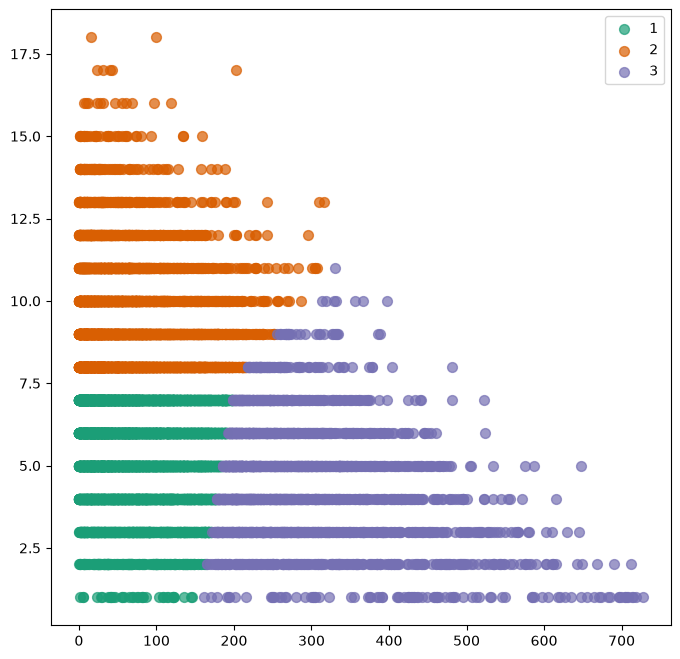

In [ ]:

# Plotting to see why
Recency = rfm_data['Recency'].values
Frequency = rfm_data['Frequency'].values

Group = rfm_data['Group'].values
Group_ = np.unique(Group)

print(Group_)
print([type(g) for g in Group_])

colors = ["#1B9E77", "#D95F02", "#7570B3"]

fig, ax = plt.subplots(figsize=(8, 8))
for group, color in zip(Group_, colors):
    i = np.where(Group == group)
    # No legend will be generated if we don't pass label=species
    ax.scatter(
        Recency[i],
        Frequency[i],
        label=group,
        s=50,
        color=color,
        alpha=0.7,
    )

ax.legend()
plt.show()

In [166]:
# Validating K-Means
sil_score = silhouette_score(rfm_normalized, model.labels_)
print(f"Silhouette Score: {sil_score}")

db_score = davies_bouldin_score(rfm_normalized, model.labels_)
print(f"Davies-Bouldin Index: {db_score}")



Silhouette Score: 0.4089584106885914
Davies-Bouldin Index: 0.8394479824400244


### Trends and Takeaways
1. Our plot doesn't show spherical convex shaped clusters
2. Silhouette and Davies Bouldin show score of 0.408 and 0.839 respectively; indicating average performance; clusters needs improvement
3. Limitations: Given the distribution, kmeans wasn't able to produce near spherical convex shaped clusters, making this algorithm not a good approach for clustering, as shown by the internal metrics and tables. 

# Part II

In [ ]:
data.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3
